# Classifying movie reviews: a binary classification example

Design a neural network to perform two-class classification or _binary classification_ , of reviews form IMDB movie reviews dataset, to determine wether the reviews are positive or negative. We will use the Python library Keras to perform the classification

## Problem Statement

Given a review, find the probability of it being a positive review or a negative review using deep neural networks.

## The IMDB Dataset

The IMDB dataset is a set of 50,000 highly polarized reviews from the Internet Movie Database. They are split into 25000 reviews each for training and testing. Each set contains equal number (50%) of positive and negative reviews.

The IMDB dataset comes packaged with Keras. It consists of reviews and their corresponding labels (0 for _negative_ and 1 for _positive_ review). The reviews are a sequence of words. They come preprocessed as sequence of integers, where each integer stands for a specific word in the dictionary.

The IMDB datset can be loaded directly from Keras and will usually download about 80 MB on your machine. 

In [4]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D


max_words = 10000


(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_words)


max_sequence_length = 500
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_sequence_length)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_sequence_length)


model = Sequential()
model.add(Embedding(max_words, 100, input_length=max_sequence_length))
model.add(GlobalMaxPooling1D())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
# The purpose of using an Embedding layer in natural language processing tasks is 
# to capture the semantic relationships between words and represent them in a meaningful and compact vector space, 
# allowing the subsequent layers of the model to learn from this representation and make accurate predictions.


# GlobalMaxPooling1D layer acts as a dimensionality reduction step 
# and provides a global view of the input sequence, enabling the model 
# to capture the most significant features and achieve efficient and effective text classification.

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

batch_size = 64
epochs = 10

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

# Generate predictions


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10


/Users/karanpatil/Desktop/Machine Learning/Python/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7677 - loss: 0.4642 - val_accuracy: 0.8673 - val_loss: 0.3117
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9014 - loss: 0.2452 - val_accuracy: 0.8809 - val_loss: 0.2831
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9428 - loss: 0.1578 - val_accuracy: 0.8767 - val_loss: 0.3018
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9675 - loss: 0.0965 - val_accuracy: 0.8727 - val_loss: 0.3468
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9862 - loss: 0.0505 - val_accuracy: 0.8686 - val_loss: 0.4064
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9949 - loss: 0.0235 - val_accuracy: 0.8676 - val_loss: 0.4632
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9990 - loss: 0.0080 - val_accuracy: 0.8662 - val_loss: 0.5316
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.8677 - val_

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step


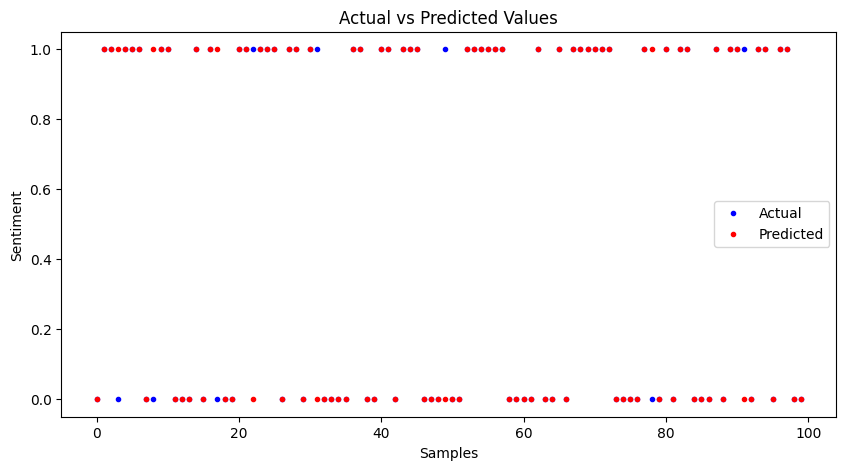

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 638us/step - accuracy: 0.8677 - loss: 0.6225
Test Loss: 0.6224537491798401
Test Accuracy: 0.8677200078964233


In [6]:
# Generate predictions
y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# Plot predicted vs actual values
plt.figure(figsize=(10, 5))
plt.plot(y_test[:100], 'b.', label='Actual')
plt.plot(y_pred[:100], 'r.', label='Predicted')
plt.title('Actual vs Predicted Values')
plt.xlabel('Samples')
plt.ylabel('Sentiment')
plt.legend()
plt.show()

loss, accuracy = model.evaluate(x_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

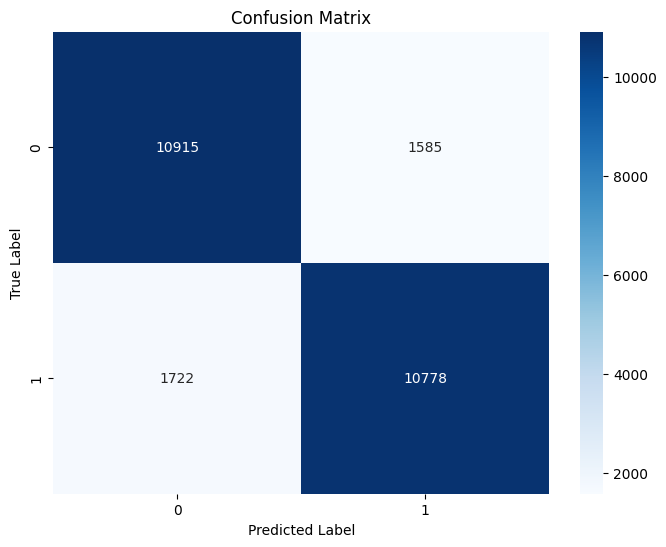

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.87     12500
           1       0.87      0.86      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



In [8]:
# Calculate metrics
cm = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report
print("Classification Report:\n", classification_rep)